# Stock Market Exploratory Data Analysis (1970–2018)

## Introduction

This project focuses on exploring historical stock market data from 1970 to 2018. The main goal is to clean, organize, and analyze daily stock price data in order to understand how stock prices and trading volumes changed across different decades.

The analysis uses two datasets: one containing historical stock prices and another containing stock information such as ticker symbols, company names, exchange, and sector. The stock price dataset includes important financial columns such as Date, Open, High, Low, Close, Volume, and Adjusted Close.

In this project, the data will be loaded, cleaned, checked for missing values and duplicates, and prepared for exploratory data analysis. A new decade column will be created to compare stock market behavior across different time periods. The analysis will include summary statistics, time series visualizations, volume distributions, and box plots for price ranges.

The final goal is to identify major trends, patterns, anomalies, and possible hypotheses that may explain changes in stock prices and trading volume over time.


## Project Workflow

1. Data Collection

2. Data Cleaning

3. Data Segmentation

4. Merge Datasets

5. Exploratory Data Analysis

6. Comparative Analysis

7. Final Conclusions

8. Future Hypotheses

## 1. Import Libraries

This section imports the Python libraries required for data manipulation, visualization, and exploratory data analysis. These libraries will be used throughout the project for loading datasets, cleaning data, performing statistical analysis, and creating visualizations.

In [60]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

# Visualization style
sns.set_style("whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


## 2. Load the Datasets

In this section, both datasets are loaded into Pandas DataFrames. The first dataset contains historical daily stock prices, while the second dataset contains information about each stock, such as ticker symbols, company names, exchanges, and sectors.

In [61]:
# Load the datasets

stocks = pd.read_csv("../data/raw/historical_stocks.csv")

stock_prices = pd.read_csv("../data/raw/historical_stock_prices.csv")

print("Datasets loaded successfully.")

Datasets loaded successfully.


In [62]:
# Display the first five rows

print("Historical Stocks Dataset")
display(stocks.head())

print("\nHistorical Stock Prices Dataset")
display(stock_prices.head())

Historical Stocks Dataset


,ticker,exchange,name,sector,industry
0,PIH,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
1,PIHPP,NASDAQ,"1347 PROPERTY INSURANCE HOLDINGS, INC.",FINANCE,PROPERTY-CASUALTY INSURERS
2,TURN,NASDAQ,180 DEGREE CAPITAL CORP.,FINANCE,FINANCE/INVESTORS SERVICES
3,FLWS,NASDAQ,"1-800 FLOWERS.COM, INC.",CONSUMER SERVICES,OTHER SPECIALTY STORES
4,FCCY,NASDAQ,1ST CONSTITUTION BANCORP (NJ),FINANCE,SAVINGS INSTITUTIONS



Historical Stock Prices Dataset


,ticker,open,close,adj_close,low,high,volume,date
0,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2013-05-08
1,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2013-05-09
2,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2013-05-10
3,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2013-05-13
4,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2013-05-14


### Initial Observation

The datasets were loaded successfully. The historical stocks dataset contains information about each company, while the historical stock prices dataset contains daily trading information including opening, closing, highest, lowest prices, trading volume, and adjusted closing prices.

## 3. Understanding the Datasets

This section explores the structure and characteristics of both datasets. Understanding the number of records, data types, missing values, and descriptive statistics is an important first step before cleaning and analyzing the data.

In [63]:
# Dataset dimensions

print("Historical Stocks Dataset Shape:", stocks.shape)
print("Historical Stock Prices Dataset Shape:", stock_prices.shape)

Historical Stocks Dataset Shape: (6460, 5)
Historical Stock Prices Dataset Shape: (20973889, 8)


In [64]:
# Column names

print("Historical Stocks Columns")
display(stocks.columns)

print("\nHistorical Stock Prices Columns")
display(stock_prices.columns)

Historical Stocks Columns


Index(['ticker', 'exchange', 'name', 'sector', 'industry'], dtype='object')


Historical Stock Prices Columns


Index(['ticker', 'open', 'close', 'adj_close', 'low', 'high', 'volume', 'date'], dtype='object')

In [65]:
# Dataset information

print("Historical Stocks Dataset Information")
stocks.info()

print("\nHistorical Stock Prices Dataset Information")
stock_prices.info()

Historical Stocks Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6460 entries, 0 to 6459
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   ticker    6460 non-null   object
 1   exchange  6460 non-null   object
 2   name      6460 non-null   object
 3   sector    5020 non-null   object
 4   industry  5020 non-null   object
dtypes: object(5)
memory usage: 252.5+ KB

Historical Stock Prices Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20973889 entries, 0 to 20973888
Data columns (total 8 columns):
 #   Column     Dtype  
---  ------     -----  
 0   ticker     object 
 1   open       float64
 2   close      float64
 3   adj_close  float64
 4   low        float64
 5   high       float64
 6   volume     int64  
 7   date       object 
dtypes: float64(5), int64(1), object(2)
memory usage: 1.3+ GB


In [66]:
# Summary statistics

print("Historical Stocks Summary")
display(stocks.describe(include="all"))

print("\nHistorical Stock Prices Summary")
display(stock_prices.describe())

Historical Stocks Summary


,ticker,exchange,name,sector,industry
count,6460,6460,6460,5020,5020
unique,6460,2,5462,13,136
top,ZYME,NASDAQ,BANK OF AMERICA CORPORATION,FINANCE,MAJOR PHARMACEUTICALS
freq,1,3308,16,1022,419



Historical Stock Prices Summary


,open,close,adj_close,low,high,volume
count,2.097389e+07,2.097389e+07,2.097389e+07,2.097389e+07,2.097389e+07,2.097389e+07
mean,7.605823e+01,7.611403e+01,1.481184e+14,7.422064e+01,7.803857e+01,1.227043e+06
std,2.849639e+03,2.870159e+03,4.574674e+16,2.746059e+03,2.997937e+03,1.316686e+07
min,4.000000e-04,2.000000e-04,2.282650e-09,1.000000e-04,4.000000e-04,1.000000e+00
25%,7.500000e+00,7.500000e+00,4.620000e+00,7.360000e+00,7.630000e+00,2.210000e+04
50%,1.545000e+01,1.545000e+01,1.138199e+01,1.524000e+01,1.566000e+01,1.260000e+05
75%,2.972000e+01,2.972000e+01,2.472046e+01,2.928000e+01,3.010000e+01,6.074000e+05
max,2.034000e+06,1.779750e+06,1.894962e+19,1.440000e+06,2.070000e+06,4.483504e+09


In [67]:
# Missing values

print("Missing Values - Historical Stocks")
display(stocks.isnull().sum())

print("\nMissing Values - Historical Stock Prices")
display(stock_prices.isnull().sum())

Missing Values - Historical Stocks


ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64


Missing Values - Historical Stock Prices


ticker       0
open         0
close        0
adj_close    0
low          0
high         0
volume       0
date         0
dtype: int64

In [68]:
# Duplicate rows

print("Duplicate Rows in Historical Stocks:", stocks.duplicated().sum())

print("Duplicate Rows in Historical Stock Prices:", stock_prices.duplicated().sum())

Duplicate Rows in Historical Stocks: 0
Duplicate Rows in Historical Stock Prices: 0


In [69]:
# Number of unique stocks

print("Number of unique companies:", stock_prices["ticker"].nunique())

print("Number of sectors:", stocks["sector"].nunique())

print("Number of exchanges:", stocks["exchange"].nunique())

Number of unique companies: 5685
Number of sectors: 13
Number of exchanges: 2


# 4. Data Cleaning

This section focuses on preparing the datasets for analysis. The quality of the analysis depends on the quality of the data. Therefore, missing values, duplicate records, and data types will be examined and handled before performing exploratory data analysis.

This notebook follows a complete Exploratory Data Analysis (EDA) workflow to understand long-term stock market behavior before applying any predictive modeling techniques.

### Business Question 1

Are the datasets clean and ready for exploratory data analysis?

To answer this question, we will examine missing values, duplicate records, and data types. Any issues identified will be handled before proceeding with the analysis.

In [70]:
# Check missing values before cleaning

print("Missing values before cleaning:")
display(stocks.isnull().sum())

Missing values before cleaning:


ticker         0
exchange       0
name           0
sector      1440
industry    1440
dtype: int64

In [71]:
# Fill missing values

stocks["sector"] = stocks["sector"].fillna("Unknown")
stocks["industry"] = stocks["industry"].fillna("Unknown")

In [72]:
# Verify missing values after cleaning

print("Missing values after cleaning:")
display(stocks.isnull().sum())

Missing values after cleaning:


ticker      0
exchange    0
name        0
sector      0
industry    0
dtype: int64

### Findings

The historical stock prices dataset did not contain any missing values.

The historical stocks dataset contained missing values in the **sector** and **industry** columns.

Instead of removing these records, the missing values were replaced with **"Unknown"** to preserve all companies while clearly indicating that the information was unavailable.

### Business Question 2

Are there any duplicate records that should be removed before the analysis?

To ensure data quality, duplicate records will be checked in both datasets. Duplicate rows can lead to biased statistics and inaccurate visualizations if they are not identified and removed.

In [73]:
# Check duplicate records before cleaning

print("Duplicate records before cleaning:")
print("Historical Stocks:", stocks.duplicated().sum())
print("Historical Stock Prices:", stock_prices.duplicated().sum())

Duplicate records before cleaning:
Historical Stocks: 0
Historical Stock Prices: 0


In [74]:
# Remove duplicate records

stocks = stocks.drop_duplicates()

stock_prices = stock_prices.drop_duplicates()

In [75]:
# Verify duplicate removal

print("Duplicate records after cleaning:")
print("Historical Stocks:", stocks.duplicated().sum())
print("Historical Stock Prices:", stock_prices.duplicated().sum())

Duplicate records after cleaning:
Historical Stocks: 0
Historical Stock Prices: 0


### Findings

No duplicate records were found in either dataset.

Although no duplicates existed, the duplicate removal step was still included as part of the data cleaning pipeline to ensure the datasets remain clean and reusable if new data is added in the future.

### Business Question 3

Is the date column stored in the correct format for time-series analysis?

The historical stock prices dataset contains a date column that is currently stored as text (object). Time-series analysis requires this column to be converted into the datetime format. After the conversion, the date column will be set as the DataFrame index to support efficient time-based operations and visualizations.

In [76]:
# Check the current data type of the date column

print("Current data type:")
print(stock_prices["date"].dtype)

Current data type:
object


In [77]:
# Convert the date column to datetime format

stock_prices["date"] = pd.to_datetime(stock_prices["date"])

In [78]:
# Verify the new data type

print("New data type:")
print(stock_prices["date"].dtype)

New data type:
datetime64[ns]


In [79]:
# Set the date column as the DataFrame index

stock_prices.set_index("date", inplace=True)

In [80]:
# Display the first five rows

stock_prices.head()

,ticker,open,close,adj_close,low,high,volume
date,,,,,,,
2013-05-08,AHH,11.50,11.58,8.493155,11.25,11.68,4633900
2013-05-09,AHH,11.66,11.55,8.471151,11.50,11.66,275800
2013-05-10,AHH,11.55,11.60,8.507822,11.50,11.60,277100
2013-05-13,AHH,11.63,11.65,8.544494,11.55,11.65,147400
2013-05-14,AHH,11.60,11.53,8.456484,11.50,11.60,184100


### Findings

The **date** column was originally stored as an object (text), which is not suitable for time-series analysis.

The column was successfully converted to the **datetime** format and set as the DataFrame index. This allows efficient filtering, grouping, resampling, and trend analysis based on time.

# 5. Data Segmentation by Decade

This section creates a new column representing the decade of each stock price record. Segmenting the data by decade allows comparison of stock market behavior across different time periods.

### Business Question 4

How can the stock price data be divided into decades for comparative analysis?

To compare stock market trends over time, a decade column will be created from the date index. This will allow the dataset to be grouped and analyzed by decade.

In [81]:
# Create a decade column from the date index

stock_prices["decade"] = (stock_prices.index.year // 10) * 10
stock_prices["decade"] = stock_prices["decade"].astype(str) + "s"

stock_prices.head()

,ticker,open,close,adj_close,low,high,volume,decade
date,,,,,,,,
2013-05-08,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2010s
2013-05-09,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2010s
2013-05-10,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2010s
2013-05-13,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2010s
2013-05-14,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2010s


In [82]:
# Count records by decade

decade_counts = stock_prices["decade"].value_counts().sort_index()
decade_counts

decade
1970s     164499
1980s    1470571
1990s    3427832
2000s    6572053
2010s    9338934
Name: count, dtype: int64

### Findings

A new **decade** column was created using the date index. This allows the dataset to be grouped into time periods such as the 1970s, 1980s, 1990s, 2000s, and 2010s.

This segmentation will support the comparative analysis required for the project.

# 6. Merge Datasets

This section combines the historical stock prices dataset with the company information dataset using the common ticker column. Merging the datasets allows stock prices to be analyzed together with company sectors, industries, and exchange information.

### Business Question 5

Why is it necessary to merge the stock prices dataset with the stock information dataset?

The stock prices dataset contains daily trading information but does not include company details such as sector, industry, or exchange. To perform a more meaningful exploratory data analysis, both datasets will be merged using the ticker column.

In [83]:
# Merge stock prices with company information

merged_data = stock_prices.merge(
    stocks,
    on="ticker",
    how="left"
)

# Restore the date index after merging
merged_data.index = stock_prices.index
merged_data.index.name = "date"

print("Merged dataset shape:", merged_data.shape)

merged_data.head()

Merged dataset shape: (20973889, 12)


,ticker,open,close,adj_close,low,high,volume,decade,exchange,name,sector,industry
date,,,,,,,,,,,,
2013-05-08,AHH,11.50,11.58,8.493155,11.25,11.68,4633900,2010s,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
2013-05-09,AHH,11.66,11.55,8.471151,11.50,11.66,275800,2010s,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
2013-05-10,AHH,11.55,11.60,8.507822,11.50,11.60,277100,2010s,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
2013-05-13,AHH,11.63,11.65,8.544494,11.55,11.65,147400,2010s,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE
2013-05-14,AHH,11.60,11.53,8.456484,11.50,11.60,184100,2010s,NYSE,"ARMADA HOFFLER PROPERTIES, INC.",FINANCE,REAL ESTATE


# 7. Exploratory Data Analysis (EDA)

This section explores stock market behavior across different decades. Summary statistics and visualizations will be used to compare price movements and trading activity over time.

### Business Question 6

How did stock price statistics change across different decades?

To answer this question, the merged dataset will first be divided into separate DataFrames based on the decade column. Summary statistics will then be calculated for each decade to compare stock market behavior over time.

In [84]:
# Create separate DataFrames for each decade

data_1970s = merged_data[merged_data["decade"] == "1970s"]

data_1980s = merged_data[merged_data["decade"] == "1980s"]

data_1990s = merged_data[merged_data["decade"] == "1990s"]

data_2000s = merged_data[merged_data["decade"] == "2000s"]

data_2010s = merged_data[merged_data["decade"] == "2010s"]

In [85]:
print("1970s:", data_1970s.shape)

print("1980s:", data_1980s.shape)

print("1990s:", data_1990s.shape)

print("2000s:", data_2000s.shape)

print("2010s:", data_2010s.shape)

1970s: (164499, 12)
1980s: (1470571, 12)
1990s: (3427832, 12)
2000s: (6572053, 12)
2010s: (9338934, 12)


### Findings

The merged dataset was successfully divided into five separate DataFrames representing the 1970s, 1980s, 1990s, 2000s, and 2010s.

This segmentation makes it easier to calculate statistics, create visualizations, and compare stock market behavior across different decades.

### Business Question 7

How do the average stock prices and trading volumes differ across decades?

To answer this question, summary statistics including the mean, median, and standard deviation will be calculated for the Open, High, Low, Close, and Volume columns for each decade.

In [86]:
# Function to calculate summary statistics

def summary_statistics(df):
    return df[["open", "high", "low", "close", "volume"]].agg(
        ["mean", "median", "std"]
    )

In [87]:
summary_1970s = summary_statistics(data_1970s)
summary_1980s = summary_statistics(data_1980s)
summary_1990s = summary_statistics(data_1990s)
summary_2000s = summary_statistics(data_2000s)
summary_2010s = summary_statistics(data_2010s)

In [88]:
print("1970s")
display(summary_1970s)

print("1980s")
display(summary_1980s)

print("1990s")
display(summary_1990s)

print("2000s")
display(summary_2000s)

print("2010s")
display(summary_2010s)

1970s


,open,high,low,close,volume
mean,12.491493,12.640192,12.366931,12.491549,7.248936e+05
median,2.791667,2.840909,2.765625,2.791667,1.872000e+05
std,46.981142,47.481931,46.513085,46.985360,1.377366e+06


1980s


,open,high,low,close,volume
mean,16.814261,17.095074,16.561523,16.824845,8.375234e+05
median,5.000000,5.083333,4.958333,5.000000,6.460000e+04
std,573.048093,582.814179,562.257404,575.029287,4.510088e+06


1990s


,open,high,low,close,volume
mean,45.291459,46.871896,43.814977,45.303495,8.635272e+05
median,10.583831,10.750000,10.437500,10.593750,6.220000e+04
std,1391.110191,1464.629619,1329.334616,1391.576526,5.834012e+06


2000s


,open,high,low,close,volume
mean,122.295850,125.646271,119.170676,122.440812,1.383562e+06
median,16.580000,16.866667,16.299999,16.584999,1.334000e+05
std,4485.636333,4703.968766,4318.821828,4509.781698,9.230143e+06


2010s


,open,high,low,close,volume
mean,65.261101,66.723946,63.917347,65.278332,1.320505e+06
median,20.010000,20.285000,19.750000,20.010000,1.654000e+05
std,1820.181589,1941.571402,1763.144292,1850.127729,1.770789e+07


### Findings

The summary statistics reveal noticeable differences in stock market behavior across decades.

- The average stock prices generally increased from the 1970s to the 2000s.
- Trading volume also increased over time, indicating higher market activity.
- The standard deviation became much larger in later decades, suggesting that stock prices became more volatile.
- The difference between the mean and median values indicates the presence of high-priced stocks that influence the overall averages.

### Business Question 8

How did the average monthly closing prices change over time within each decade?

To identify long-term trends and reduce daily fluctuations, the daily closing prices will be resampled into monthly average closing prices for each decade. Time-series plots will then be created to visualize how stock prices changed over time.

In [89]:
# Function to calculate monthly average closing prices

def monthly_average(df):
    return df["close"].resample("ME").mean()

In [90]:
monthly_1970s = monthly_average(data_1970s)
monthly_1980s = monthly_average(data_1980s)
monthly_1990s = monthly_average(data_1990s)
monthly_2000s = monthly_average(data_2000s)
monthly_2010s = monthly_average(data_2010s)

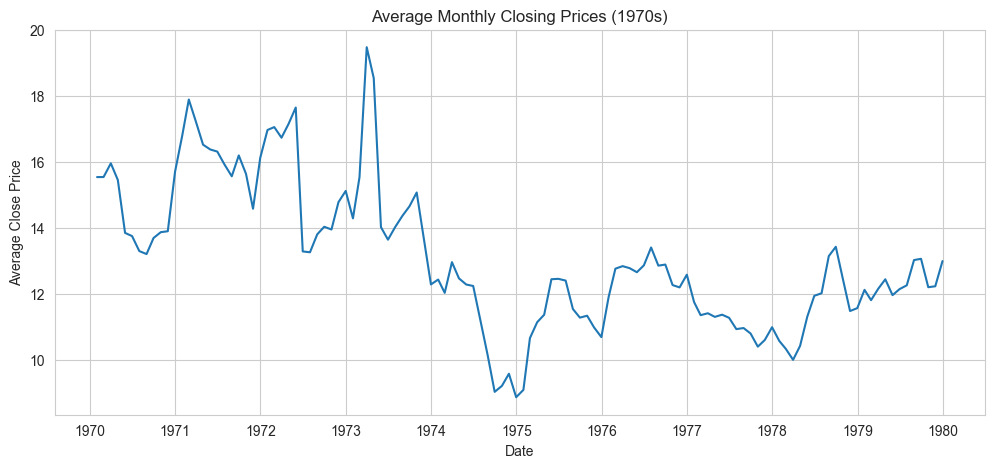

In [91]:
plt.figure(figsize=(12,5))

plt.plot(monthly_1970s)

plt.title("Average Monthly Closing Prices (1970s)")

plt.xlabel("Date")

plt.ylabel("Average Close Price")

plt.show()

In [92]:
# Function to plot monthly average closing prices

def plot_monthly_close(monthly_data, decade):

    plt.figure(figsize=(12,5))

    plt.plot(monthly_data)

    plt.title(f"Average Monthly Closing Prices ({decade})")

    plt.xlabel("Date")

    plt.ylabel("Average Close Price")

    plt.grid(True)

    plt.show()

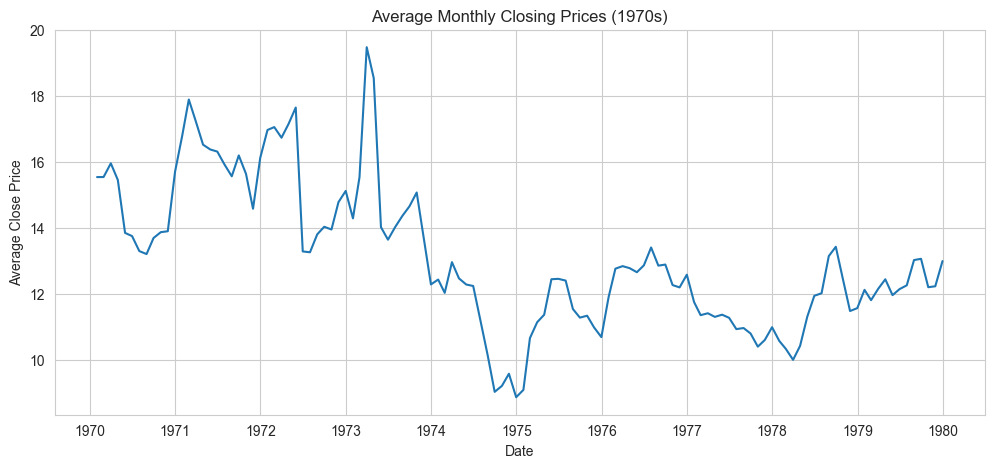

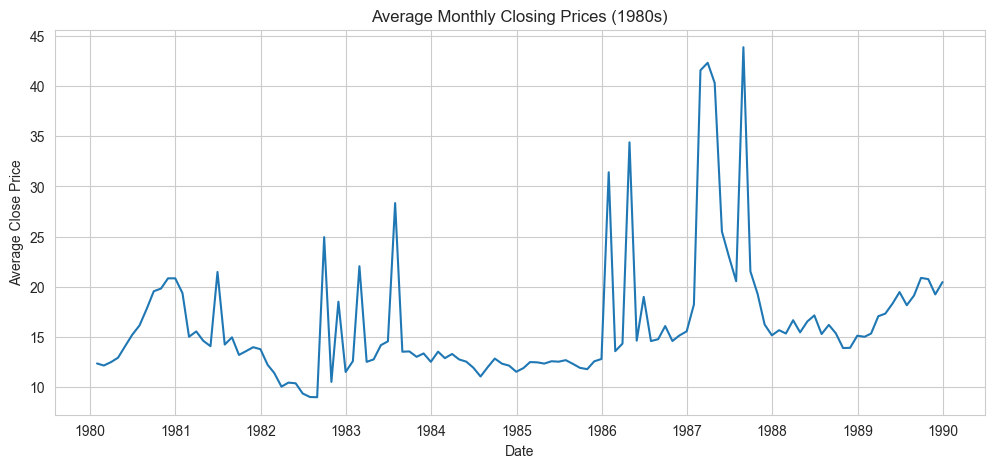

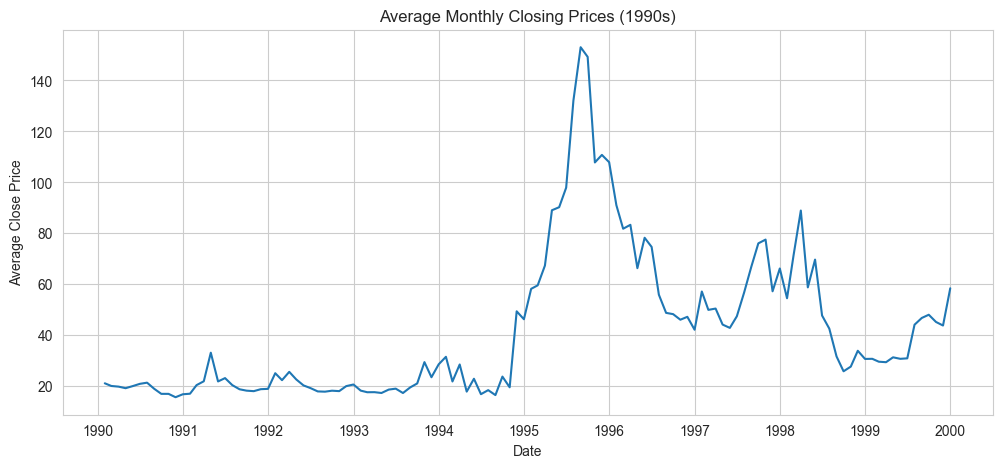

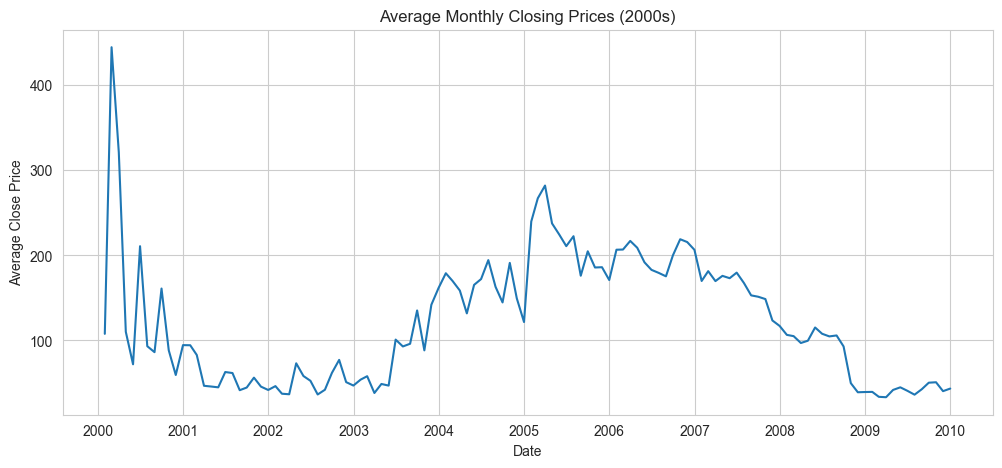

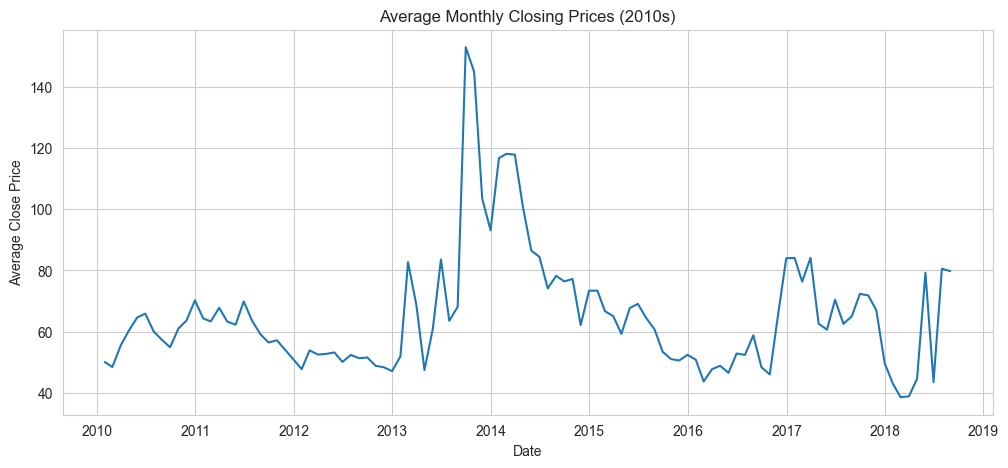

In [93]:
plot_monthly_close(monthly_1970s, "1970s")

plot_monthly_close(monthly_1980s, "1980s")

plot_monthly_close(monthly_1990s, "1990s")

plot_monthly_close(monthly_2000s, "2000s")

plot_monthly_close(monthly_2010s, "2010s")

### Findings

The monthly average closing price plots reveal different market behaviors across the decades.

- The 1970s showed relatively stable prices with moderate fluctuations.
- The 1980s experienced higher volatility with several sharp price movements.
- The 1990s displayed a strong upward trend followed by a correction.
- The 2000s included periods of both growth and decline, indicating changing market conditions.
- The 2010s showed moderate fluctuations with one major price spike before stabilizing.

Overall, the visualizations indicate that stock market behavior evolved over time, with later decades generally showing greater price variability than earlier decades.

### Business Question 9

How is trading volume distributed across different decades?

To understand trading activity across decades, histograms will be used to visualize the distribution of trading volume. This helps identify whether trading volumes are concentrated around certain values or contain extreme observations.

In [94]:
# Function to plot volume distribution

def plot_volume_histogram(df, decade):

    plt.figure(figsize=(10,5))

    plt.hist(df["volume"], bins=30)

    plt.title(f"Trading Volume Distribution ({decade})")

    plt.xlabel("Volume")

    plt.ylabel("Frequency")

    plt.grid(True)

    plt.show()

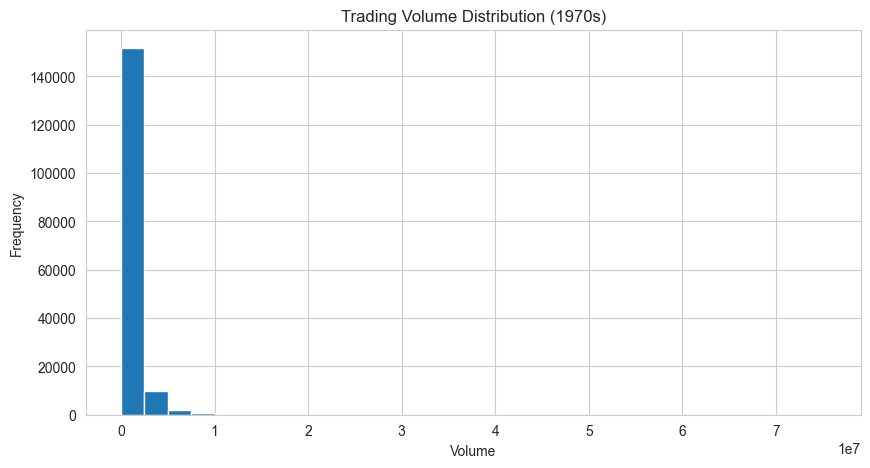

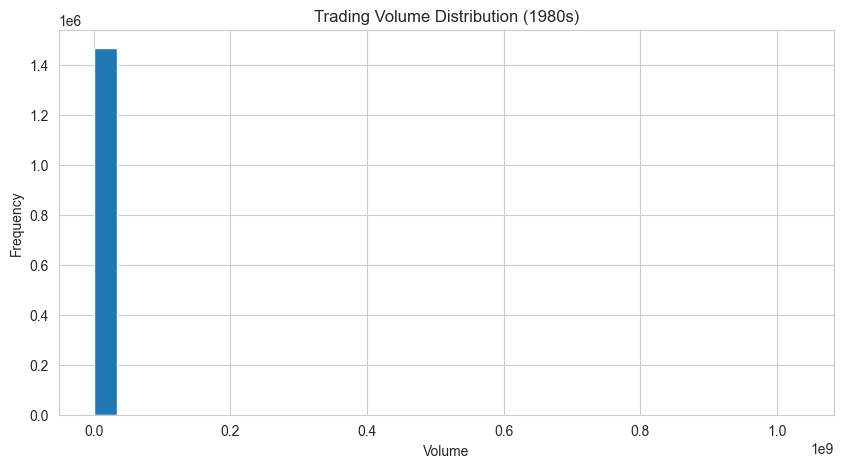

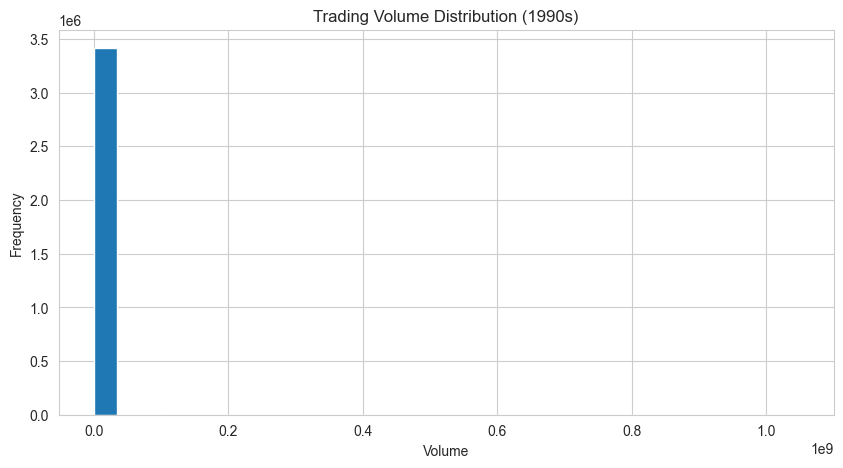

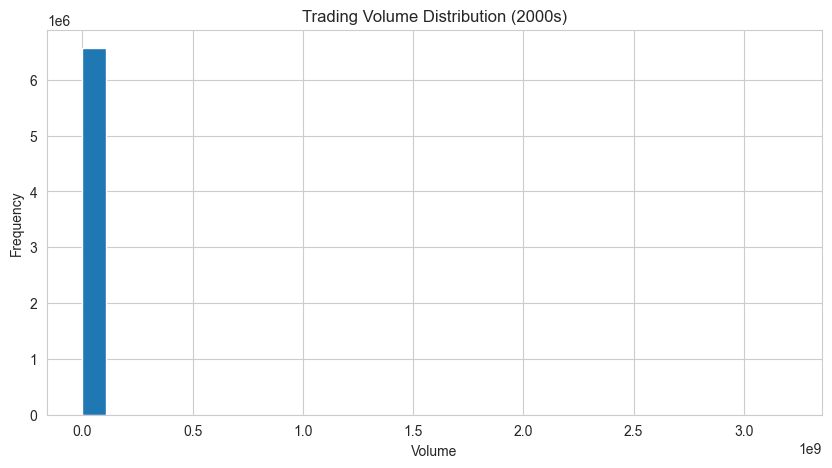

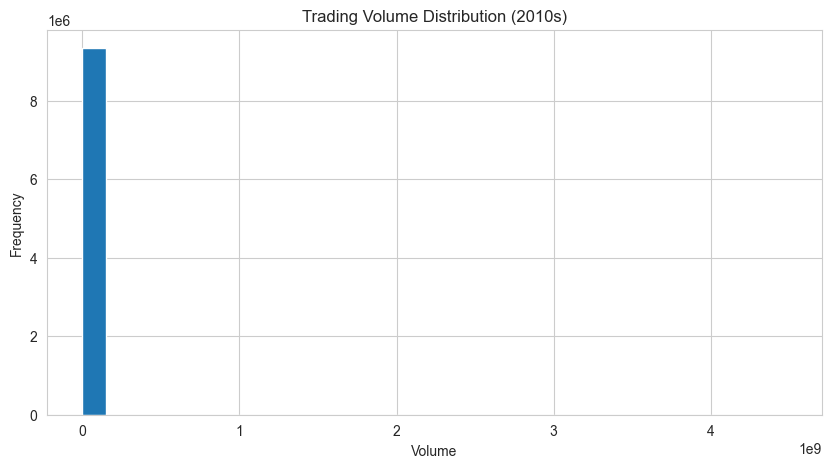

In [95]:
plot_volume_histogram(data_1970s, "1970s")

plot_volume_histogram(data_1980s, "1980s")

plot_volume_histogram(data_1990s, "1990s")

plot_volume_histogram(data_2000s, "2000s")

plot_volume_histogram(data_2010s, "2010s")

### Business Question 10

How do the High and Low stock prices vary across different decades, and are there any outliers?

To examine the spread of stock prices and identify potential outliers, box plots will be created for the High and Low price columns for each decade.

In [96]:
# Function to plot High and Low price boxplots

def plot_price_boxplot(df, decade):

    plt.figure(figsize=(8,6))

    plt.boxplot(
        [df["high"], df["low"]],
        labels=["High", "Low"]
    )

    plt.title(f"High and Low Price Distribution ({decade})")

    plt.ylabel("Price")

    plt.grid(True)

    plt.show()

C:\Users\moham\AppData\Local\Temp\ipykernel_15176\1743288510.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


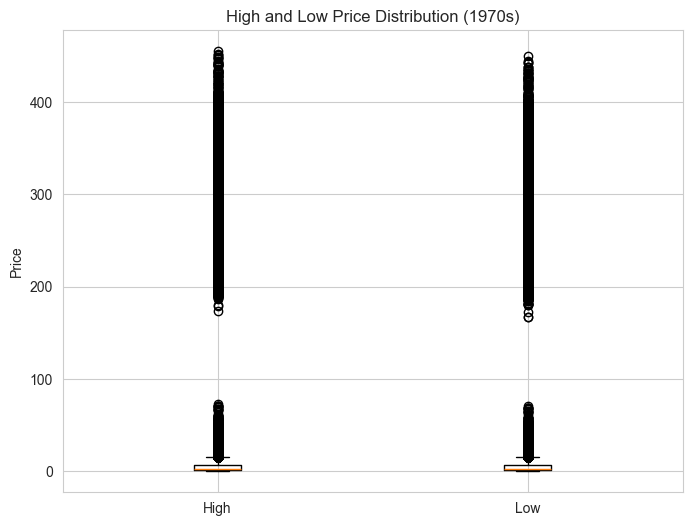

C:\Users\moham\AppData\Local\Temp\ipykernel_15176\1743288510.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


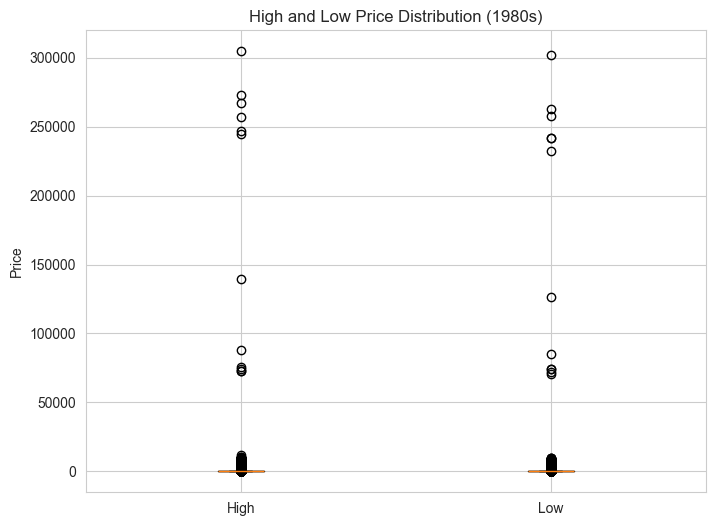

C:\Users\moham\AppData\Local\Temp\ipykernel_15176\1743288510.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


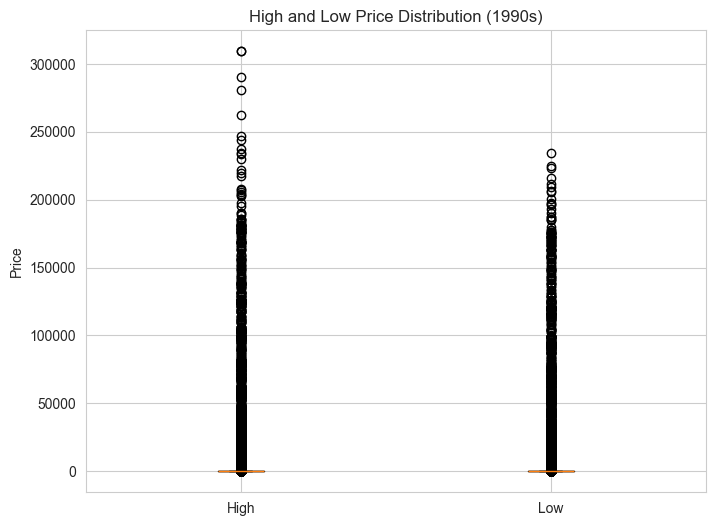

C:\Users\moham\AppData\Local\Temp\ipykernel_15176\1743288510.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


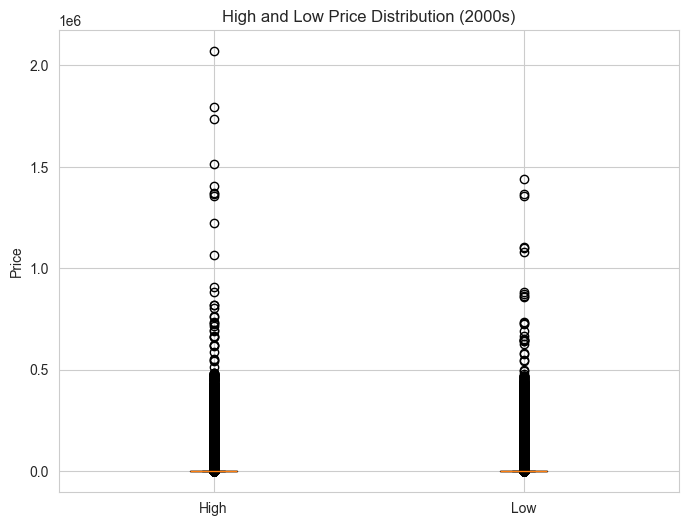

C:\Users\moham\AppData\Local\Temp\ipykernel_15176\1743288510.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


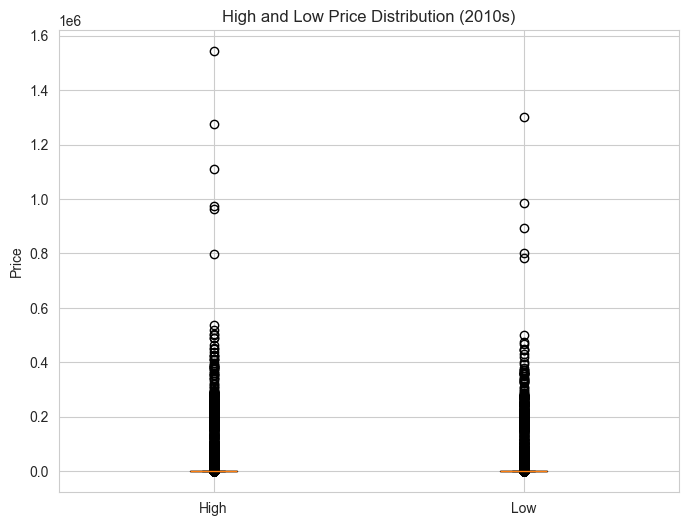

In [97]:
plot_price_boxplot(data_1970s, "1970s")

plot_price_boxplot(data_1980s, "1980s")

plot_price_boxplot(data_1990s, "1990s")

plot_price_boxplot(data_2000s, "2000s")

plot_price_boxplot(data_2010s, "2010s")

### Findings

The box plots show that stock prices contain numerous outliers across all decades.

The later decades generally display a wider spread of prices, indicating increased market variability compared to the 1970s.

The larger spread of the boxes and whiskers, together with the presence of many outliers, suggests that stock prices became more volatile over time.

These observations are consistent with the increasing standard deviation observed in the summary statistics.

# 8. Comparative Analysis

This section compares the summary statistics and visualizations across different decades to identify long-term changes in stock prices, trading activity, and market behavior.

### Business Question 11

What long-term trends can be observed in stock prices across different decades?

To answer this question, the summary statistics and time-series visualizations will be compared to identify long-term changes in average stock prices and overall market trends.

### Findings

The analysis shows that stock prices changed noticeably across the decades.

- The average stock prices generally increased from the 1970s through the 2000s.
- The time-series plots revealed that later decades experienced stronger upward and downward price movements than earlier decades.
- The 1970s displayed relatively stable price behavior, while the 1990s and 2000s showed more pronounced trends and larger price movements.
- Overall, the stock market became more dynamic over time, with greater variation in monthly closing prices.

### Business Question 12

How did trading volume and market volatility change over time?

To answer this question, the trading volume statistics, histograms, box plots, and standard deviation values will be compared across decades.

### Findings

The analysis indicates that both trading activity and market volatility increased over time.

- The average trading volume generally increased in the later decades, suggesting greater market participation.
- The standard deviation values became substantially larger, indicating higher price volatility.
- The box plots showed a wider spread of prices in later decades compared to the 1970s.
- The volume histograms revealed highly right-skewed distributions, indicating that most trading days had moderate trading volumes while a relatively small number of days experienced extremely high trading activity.

### Business Question 13

What consistent patterns and anomalies were observed throughout the analysis?

To answer this question, all statistical summaries and visualizations are reviewed together to identify recurring patterns and unusual observations across the dataset.

### Findings

Several consistent patterns were identified throughout the analysis.

- Stock prices contained numerous outliers across every decade.
- The difference between the mean and median values suggested that high-priced stocks influenced the average prices.
- Multiple visualizations confirmed that market variability increased over time.
- The statistical summaries and visualizations consistently supported one another, increasing confidence in the overall findings.

# 9. Final Conclusions and Future Hypotheses

This final section summarizes the key findings of the exploratory data analysis and proposes several hypotheses that could be investigated in future studies using more advanced statistical or machine learning techniques.

### Business Question 14

What are the main conclusions from the exploratory data analysis?

The overall results from the data cleaning, statistical analysis, and visualizations are reviewed to summarize the most important observations from this project.

### Final Conclusions

The exploratory data analysis provided valuable insights into historical stock market behavior between 1970 and 2018.

- The datasets were successfully cleaned and prepared for analysis with no duplicate records and all missing values appropriately handled.
- Stock prices changed considerably across different decades, with later decades generally showing greater price variability than earlier decades.
- Trading volume increased substantially over time, suggesting higher levels of market activity and investor participation.
- Multiple visualizations consistently showed that stock prices became more volatile over the years.
- The combination of summary statistics and visualizations provided a consistent understanding of long-term stock market trends.

### Business Question 15

What hypotheses could be investigated in future analyses?

The exploratory analysis revealed several interesting patterns that could be examined further using statistical testing or machine learning models.

### Future Hypotheses

Based on the exploratory data analysis, the following hypotheses could be explored in future projects:

- Companies from different sectors may exhibit different long-term price trends.
- Higher trading volume may be associated with increased price volatility.
- Certain industries may experience stronger growth during specific economic periods.
- Historical stock prices may be used to develop predictive machine learning models for future price movements.
- Seasonal patterns may influence stock prices during particular months or years.

## Project Summary

This project successfully explored historical stock market data from 1970 to 2018 through a complete exploratory data analysis workflow.

The project included data collection, cleaning, preparation, segmentation by decade, dataset merging, statistical analysis, and multiple visualizations. The findings revealed meaningful long-term trends in stock prices, trading activity, and market variability.

The completed analysis provides a strong foundation for future predictive analytics and machine learning applications using historical financial data.

## End of Project

Thank you for reviewing this exploratory data analysis project. The completed workflow provides a strong foundation for future predictive analytics and machine learning applications using historical stock market data.